In [1]:
import time
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input

In [2]:
path = "/content/drive/MyDrive/Aprendizado - Notebooks Colab/ResNet50V2 Transfer Learning/archive"
train_path = path + "/train"
val_path = path + "/val"
test_path = path + "/test"

# ResNet50V2 Transfer Learning on a Chest X-Ray Pneumonia Classification

# Equipe:
*   Carlos Henrique Miranda Esteves;
*   Lucas Almeida Miralha de Figueiredo;
*   Lucas Andrey Nunes de Aragão.

# Overview:

O projeto "ResNet50V2 Transfer Learning on a Chest X-Ray Pneumonia Classification" é baseado na pesquisa [Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning](https://www.cell.com/cell/fulltext/S0092-8674(18)30154-5), no qual os pesquisadores utilizaram o método de transfer learning na classificação de degeneração macular relacionada à idade e edema macular diabético através de imagens tomografia de coerência óptica (OCT). Os pesquisadores também demonstraram a eficiência do modelo na classificação pediátrica de pneumonia com base em imagens de raio-x do toráx.

Os dados utilizados neste trabalho foram extraídos do repositório Kaggle: [Chest X‑Ray Pneumonia — Balanced Dataset](https://www.kaggle.com/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/data). As imagens deste repositório são as mesmas imagens utilizadas no estudo acima. Para o nosso experimento, configuramos o modelo CNN ResNet50V2 para classificação de imagens através do procedimento de transfer learning via Keras Tensorflow. Outros modelos CNN também podem ser utilizados para a tarefa de classificação de imagens.

Este notebook colab é responsável por: processar os dados, configurar e adaptar o modelo ResNet50V2 via transfer learning, treinamento do modelo, plotagem e análise de dados e exploração do GridSearch

# Direitos Autorais

As imagens utilizadas neste notebook colab são de autoria de Aurélien Geron, autor do livro Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow. Imagens, explicações teóricas do funcionamento do uso de CNN's e código fonte são de autoria de Aurélien Geron. Link para aquisição do livro: [Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow](https://www.amazon.com.br/Mãos-Obra-Aprendizado-Scikit-Learn-Inteligentes/dp/8550826456/ref=sr_1_2?crid=12PQ0NFG10U49&dib=eyJ2IjoiMSJ9.N97X5WDhjZrNKhN1w0I4znhJnfHqAy9_UsfvUtPRPplPQNhm-3qRg6J_DPD4UF7ua3frSmbDIzTZzenfqLo25KoWZqmUZnWcIPLx3xvdASTsdpk7YjbdOoUIt22sF_jJ2oz5qGsIQp-0EhgUJVkg6dIXVh_pTwtkr7Dp3Hz4QKqYLmuLaKtXe88Nyrabddle.HOR18zUrW2LwoouaHiVCQ_lihQ5iDr4lKWHz63BD_Y4&dib_tag=se&keywords=mãos+a+obra+aprendizado+de+maquina&qid=1774744923&sprefix=%2Caps%2C212&sr=8-2)

# Uso de IA Generativa

Durante a confecção deste experimento, a IA generativa Gemini 3 - Raciocínio foi utilizada nos seguintes aspectos:


*   Fundamentação Teórica e Conceitual (aprendizado teórico);
*   Adaptação do Código do Autor Para o Modelo Utilizado Neste Experimento;
*   Decisões Relacionado ao Uso de GPU;
*   Edições, Formulações e Contribuições de Código;
*   Auxílio na Tomada de Decisões Relacionadas a Partes Críticas de Configuração da CNN;
*   Escrita Parcial de Texto.





# 1°: Processamento de Dados

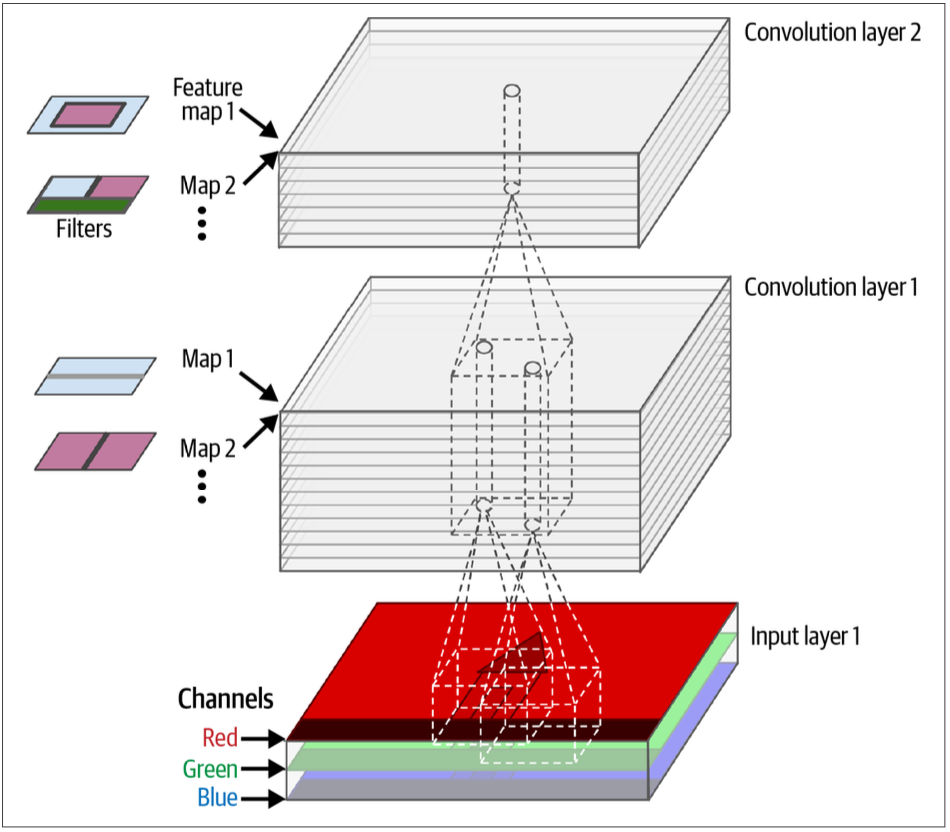
A primeira etapa antes de executar o ResNet50V2 consiste em tratar os dados. No nosso caso, os dados que serão introduzidos no modelo são imagens de raios-x do tórax. O modelo ResNet50V2 tem entradas de 224 por 224. Por padrão, o ResNet50V2 Transfer Learning tem arquitetura que aceita entradas RGB (canal 3 de entrada), nosso dataset tem somente 1 canal de tons de cinza. O modelo ResNet50V2 possui 25.5 milhões de parâmetros.

Na primeira etapa, estamos preocupados em realizar as seguintes tarefas:


1.   Padronizar o tamanho dos dados para os inputs do ResNet50V2;
2.   Padronizar o tamanho do canal dos dados para para os inputs do ResNet50V2;
3.   Dividir o dataset em: treino, validação e teste;
4.   Realizar o processo de augmentação de dados.



In [3]:
# Tamanho do Batch de Dados
BATCH_SIZE = 64

# Padronização do tamanho das imagens para o input do ResNet50V2
IMG_SIZE = (224, 224)

# Mesmo sendo um canal (tons de cinza), o ResNet50V2 de transfer learning
# espera trabalhar com RGB
IMG_SHAPE = IMG_SIZE + (3,)

# Carga do dataset de treinamento (necessário embaralhamento dos dados)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    label_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE)

# Carga do dataset de treinamento
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    label_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE)

# Carga do dataset de treinamento (caso necessário)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    label_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE)

Found 6800 files belonging to 2 classes.
Found 6800 files belonging to 2 classes.
Found 30 files belonging to 2 classes.


In [4]:
# Augmentação de dados:
# Apesar do dataset possui 6800 dados, ainda precisamos do processo de augmenta-
# de dados. A augmentação de dados é um processo que permite expandir a amostra
# de dados originais aplicando flips, rotações e zooms na amostra original, ge-
# rando "novos" dados.

data_augmentation = tf.keras.Sequential([
                    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
                    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
                    tf.keras.layers.RandomZoom(0.1, seed=42)
])

# 2°: Personalização do Modelo Transfer Learning ResNet50V2

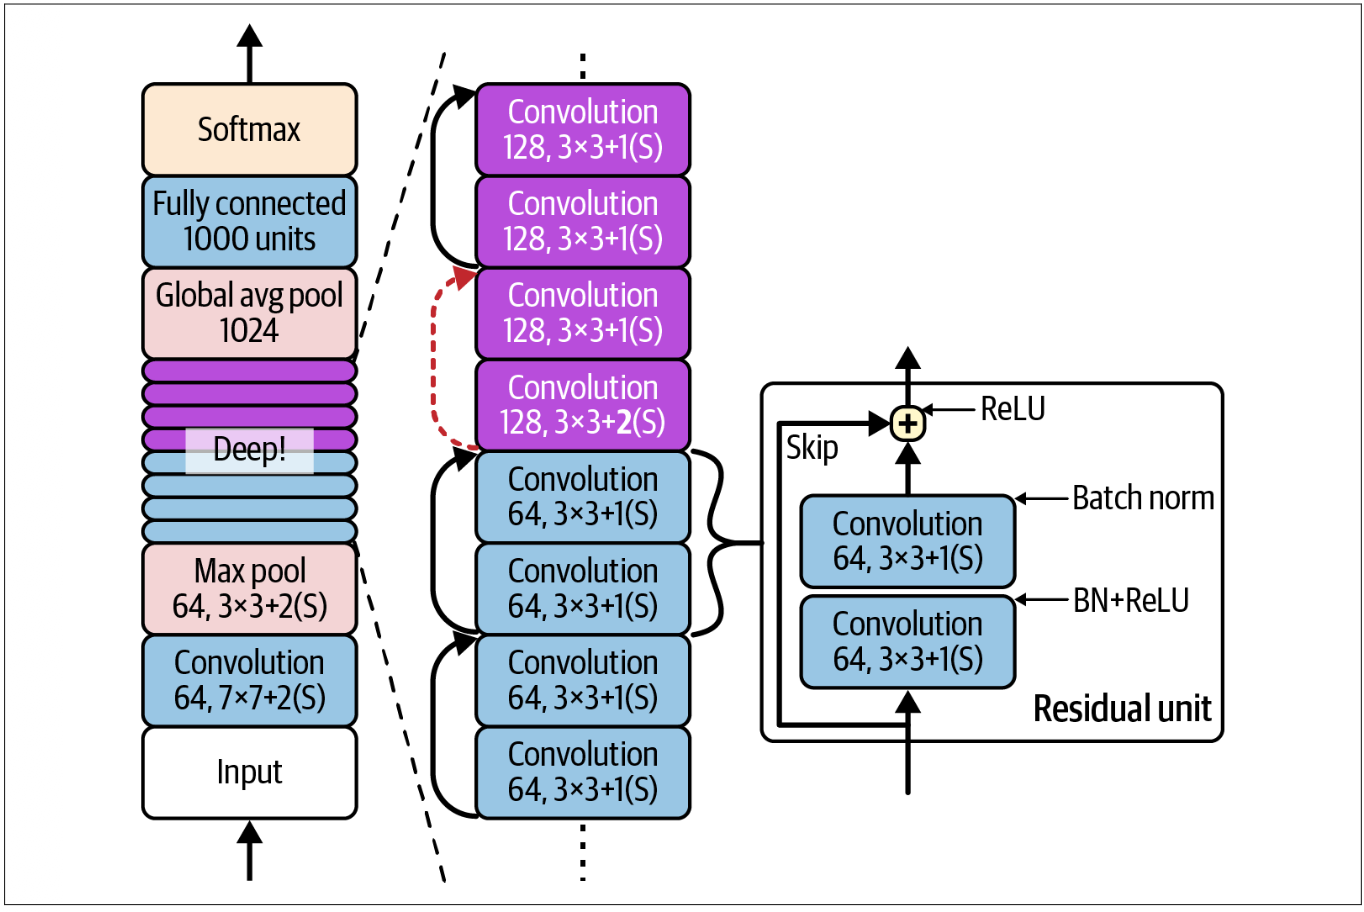

Nesta seção, não implementaremos o modelo ResNet50 do 0. Ao invés disso, vamos recorrer a técnica do transfer learning: vamos utilizar uma CNN pronta capaz de reconhecer imagens (em torno de 1000 classes) com parâmetros prontos e vamos reconfigurar o modelo para o nosso problema: classificar as imagens em somente duas classes: com pneumonia e sem pneumonia.

Para tornar isso possível, precisamos fazer umas modificações, a primeira delas é o topo do modelo. Como é possível ver na imagem de cima, o topo apresenta três unidades importantes: saida softmax, camada densa conectada com 1000 unidades e um global avarage pool de 1024 pontos. Nosso objetivo é gerar somente duas saídas, portanto, precisamos remover a classificação de 1000 unidades

In [5]:
# Importação do modelo ResNet50V2, excluindo o topo. Os parâmetros iniciais são
# os parâmetros do imagenet
base_model = ResNet50V2(input_shape=IMG_SHAPE,
                         include_top=False,
                         weights='imagenet')

# O transfer learning deve preservar partes dos parâmetros da CNN original, en-
# quanto utiliza o restante dos parâmetros para treinar e classificar novas ima-
# gens. Por isso, o código abaixo congela as camadas iniciais.
for layer in base_model.layers:
  layer.trainable = False

In [6]:
# Configurando o tamanho do Input como (224, 224, 3)
inputs = tf.keras.Input(shape=IMG_SHAPE)

# Adiciona o processo de augmentação de dados no treinamento
x = data_augmentation(inputs)

# Aqui pre processamos as imagens. Alguns modelos precisam que a imagem vá de 0
# a 1, outros precisam que a imagem vá de -1 a 1.
x = preprocess_input(x)

# Configurando saída do modelo
x = base_model(x, training=False)

# Configurações da Camado do Topo

#  Configuração do Pooling Layer
x = layers.GlobalAveragePooling2D()(x)

# Configuração da Camada Densa
# Configuração da camada densa com 128 unidades de informação (tente mudar para
# ver se a precisão aumenta ou diminui)
x = layers.Dense(128, activation='relu')(x)

# Configuração do dropout para desativação de 30% dos neurônios durante os testes
x = layers.Dropout(0.3)(x)

# Camada final com um único neurônio, podendo ter o diagnóstico de 0.0 a 1.0
outputs = layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,201 (90.89 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

# 3°: Treinamento

Por fim, a ultima etapa é a etapa de treinamento. Aqui temos algumas configurações importantes: otimizador, parâmetros do otimizador, metricas que desejamos analisar etc. As principais métricas que precisamos utilizar são: accuracy, precisão, recall e auc. Abaixo, definimos alguns dos possíveis resultados do nosso treinamento e classificação:

*   **Verdadeiro Positivo (TP):** O modelo classificou como "Doente" e a pessoa está doente.
*   **Verdadeiro Negativo (TN):** O modelo classificou como "Saudável" e a pessoa está saudável.
*   **Falso Positivo (FP):** O modelo classificou como "Doente", mas a pessoa está saudável (Alarme Falso).
*   **Falso Negativo (FN):** O modelo classificou como "Saudável", mas a pessoa está doente (Erro Perigoso).

Todos esse possíveis resultados que podemos obter da nossa classificação, permite criar algumas métricas de avaliação do desempenho do modelo:



1.   **Accuracy (Acurácia):** de tudo o que o modelo previu, quanto ele acertou no total (tanto positivos quanto negativos).
$$\text{Acurácia} = \frac{TP + TN}{\text{Total de casos}}$$

2.   **Precision (Precisão):** De todos os que o modelo classificou como positivos, quantos eram realmente positivos?
$$\text{Precisão} = \frac{TP}{TP + FP}$$

3.   **Recall:** De todos os que são realmente positivos na vida real, quantos o modelo conseguiu encontrar? Devemos considerar essa métrica para verificar os falsos positivos e evitar submeter uma pessoa a um tratamento desnecessário
$$\text{Recall} = \frac{TP}{TP + FN}$$

4.   **Area Under the Curve (Área Sobre a Curva):** mede a capacidade de separação do modelo. Ou seja, o quão bem o seu modelo consegue distinguir entre a classe 0 e a classe 1.

In [7]:
# Aqui compilamos várias informações de uma vez: otimizador, entropia binária
# cruzada, métricas como a precisão, accuracy, recall e auc.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[
                  'accuracy',
                  tf.keras.metrics.Precision(name='precision'),
                  tf.keras.metrics.Recall(name='recall'),
                  tf.keras.metrics.AUC(name='auc')
              ])

In [8]:
# Aqui configuramos uma parada. Caso a rede não melhore, devemos interromper o
# processo de aprendizado
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                  patience=5,
                                                  restore_best_weights=True)

In [9]:
# Por fim, executamos o processo de treinamento com 10 épocas
# Nota: uma época é quantas vezes o modelo vai varrer o dataset de treinamento
# do início ao fim. Esse procedimento é necessário para que o modelo aprenda
# através do conjunto de treinamento. Varrer uma única vez nunca é o suficiente
epochs = 10
print(f'Iniciando treino de {epochs} épocas com base congelada...')
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=validation_dataset,
    callbacks=[early_stopping]
)

Iniciando treino de 10 épocas com base congelada...
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 99s 826ms/step - accuracy: 0.9065 - auc: 0.9695 - loss: 0.2222 - precision: 0.9096 - recall: 0.9026 - val_accuracy: 0.9535 - val_auc: 0.9918 - val_loss: 0.1214 - val_precision: 0.9710 - val_recall: 0.9350
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 247ms/step - accuracy: 0.9503 - auc: 0.9883 - loss: 0.1343 - precision: 0.9543 - recall: 0.9459 - val_accuracy: 0.9656 - val_auc: 0.9944 - val_loss: 0.1000 - val_precision: 0.9588 - val_recall: 0.9729
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 241ms/step - accuracy: 0.9569 - auc: 0.9898 - loss: 0.1236 - precision: 0.9595 - recall: 0.9541 - val_accuracy: 0.9253 - val_auc: 0.9939 - val_loss: 0.1787 - val_precision: 0.9935 - val_recall: 0.8562
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 246ms/step - accuracy: 0.9566 - auc: 0.9911 - loss: 0.1161 - precision: 0.9581 - recall: 0.9550 - val_accuracy: 0.9668 - val_auc: 0.9962 - val_loss: 0.0892 - val_precisi

# 4°: Plotagem dos resultados

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

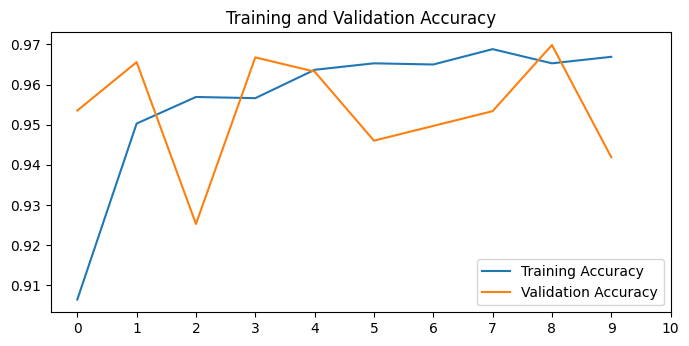

In [11]:
# Gráfico de acurácias (treino e validação)
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xticks(range(0, 11))
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

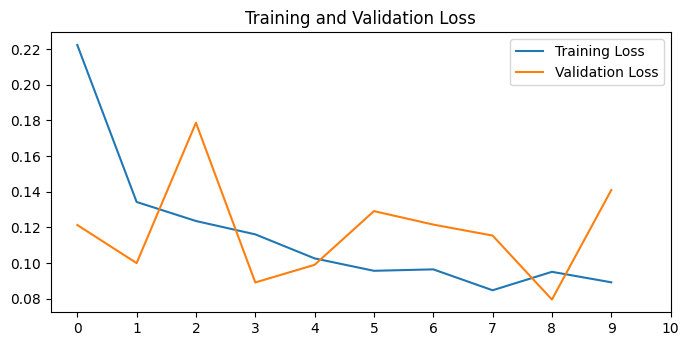

In [12]:
# Gráfico de perdas (treino e validação)
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xticks(range(0, 11))
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

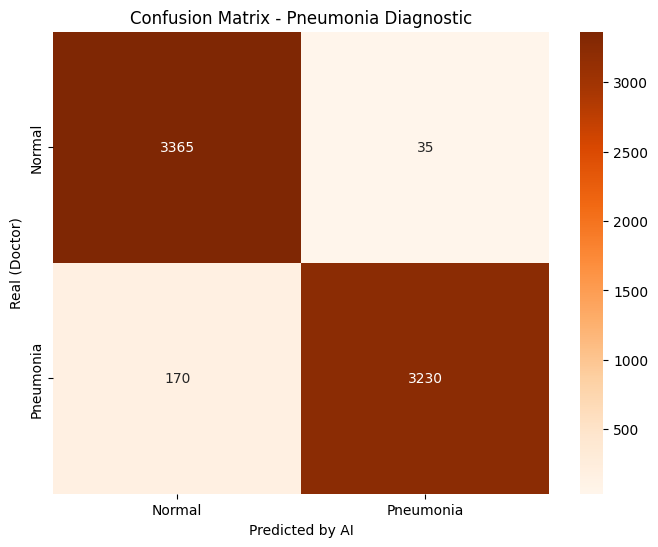

              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97      3400
   Pneumonia       0.99      0.95      0.97      3400

    accuracy                           0.97      6800
   macro avg       0.97      0.97      0.97      6800
weighted avg       0.97      0.97      0.97      6800



In [13]:
# Aqui, plotamos uma matriz de confusão
y_true = []
y_pred = []

# Pegando as imagens e os labels do dataset de validação
for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    # Como a saída da Sigmoid é probabilidade (0 a 1), usamos o limiar de 0.5
    y_pred.extend((preds > 0.5).astype(int))

# Aqui geramos a matriz
cm = confusion_matrix(y_true, y_pred)

# Plotando o gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted by AI')
plt.ylabel('Real (Doctor)')
plt.title('Confusion Matrix - Pneumonia Diagnostic')
plt.show()

# Relatório completo (Precision, Recall, F1)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

# 5°: Analise individual de Hiperparâmetros

Encontrar os hiperparâmetros corretos através do Gridearch não foi uma tarefa exautiva. O ResNet50V2 ainda possui vários hiperparâmetros que podemos escolher para explorar e ver se a acurácia do modelo apresenta melhora ou não. Para este experimento, vamos focar na última camada responsável pela classificação: a camada densa. A camada densa é uma camada supercompressora. A camada média de Pooling comprime todos os mapas de características geradas em um único vetor que alimenta os neurônios camada densa, que por sua vez, são responsáveis por gerar a classificação binária.

Quanto menor a quantidade de neurônios da camada densa, maior será a compressão de informações, o que forçará o modelo a encontrar padrões em objetos maiores: costelas, pulmões corações etc. Quanto maior a quantidade de neurônios, menor será a compressão de informações, o que forçará o modelo a encontrar padrões em objetos menores: pixels, linhas e contornos. Precisamos encontrar um meio termo de compressão de informação e detecção de padrões.

In [14]:
# Listas de números da camada densa
# Nota: A quantidade de neurônios aumenta consideravelmente a quantidade de pa-
# râmetros e de tempo de execução
dense_layer_neurons = [64, 128, 256, 512, 1024]

# Aqui armazenamos os registros
results = []
histories = {}
models = {}

In [15]:
def build_resnet_model(neurons_number):
    # 1. Carregar modelo base
    base_model = ResNet50V2(input_shape=IMG_SHAPE,
                            include_top=False,
                            weights='imagenet')

    for layer in base_model.layers:
      layer.trainable = False

    # 2. Construção do Grafo (API Funcional)
    img_input = tf.keras.Input(shape=IMG_SHAPE, name="original_input")

    x = data_augmentation(img_input)
    x = preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    # Aqui configuramos a quantidade de neurônios que a camada densa vai ter.
    x = layers.Dense(neurons_number, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    # 3. Definição do Modelo (Input original -> Output final)
    model = tf.keras.Model(img_input, outputs)

    # 4. Configuração do Otimizador Adam
    opt = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [16]:
count = 1
for neurons_number in dense_layer_neurons:

  print(f"\nRodando Combinação {count}/5: Número de Neurônios: {neurons_number}")

  # Função build_resnet_model declarada acima
  model = build_resnet_model(neurons_number)

  # Callback para early stopping
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                        patience=5,
                                        restore_best_weights=True)
  # Treino para o Grid Search
  start_time = time.time()
  history = model.fit(
      train_dataset,
      validation_data=validation_dataset,
      epochs=10,
      verbose=1,
      callbacks=[early_stopping]
  )
  end_time = time.time()

  # Registrar resultados
  max_val_acc = max(history.history['val_accuracy'])
  results.append({
      'combinacao': count,
      'neurons_number': neurons_number,
      'val_accuracy': max_val_acc,
      'training_time': end_time - start_time
  })

  histories[neurons_number] = history
  models[neurons_number] = model
  count += 1

  # Limpar memória para a próxima rodada (isso evita explosão da minha
  # GPU)
  tf.keras.backend.clear_session()

# Converter para DataFrame para o relatório
df_results = pd.DataFrame(results)


Rodando Combinação 1/5: Número de Neurônios: 64
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 259ms/step - accuracy: 0.9149 - loss: 0.2185 - val_accuracy: 0.9491 - val_loss: 0.1330
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.9499 - loss: 0.1344 - val_accuracy: 0.9485 - val_loss: 0.1272
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.9556 - loss: 0.1250 - val_accuracy: 0.9499 - val_loss: 0.1260
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.9599 - loss: 0.1094 - val_accuracy: 0.9619 - val_loss: 0.0980
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.9615 - loss: 0.1043 - val_accuracy: 0.9540 - val_loss: 0.1145
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.9653 - loss: 0.0955 - val_accuracy: 0.9597 - val_loss: 0.1059
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.9579 - loss: 0.1075 - val_accuracy: 0.9612 - val_loss: 0.1036
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━

In [17]:
# Melhor combinação por acurácia de validação.
df_results = df_results.sort_values(by='val_accuracy', ascending=False)
display(df_results)

best_config = df_results.iloc[0]

,combinacao,neurons_number,val_accuracy,training_time
1,2,128,0.977941,264.654809
0,1,64,0.975441,264.461643
4,5,1024,0.974853,264.833418
3,4,512,0.973088,264.560035
2,3,256,0.970735,213.316969


# 6°: Gráficos da Busca Individual de Hiperparâmetros

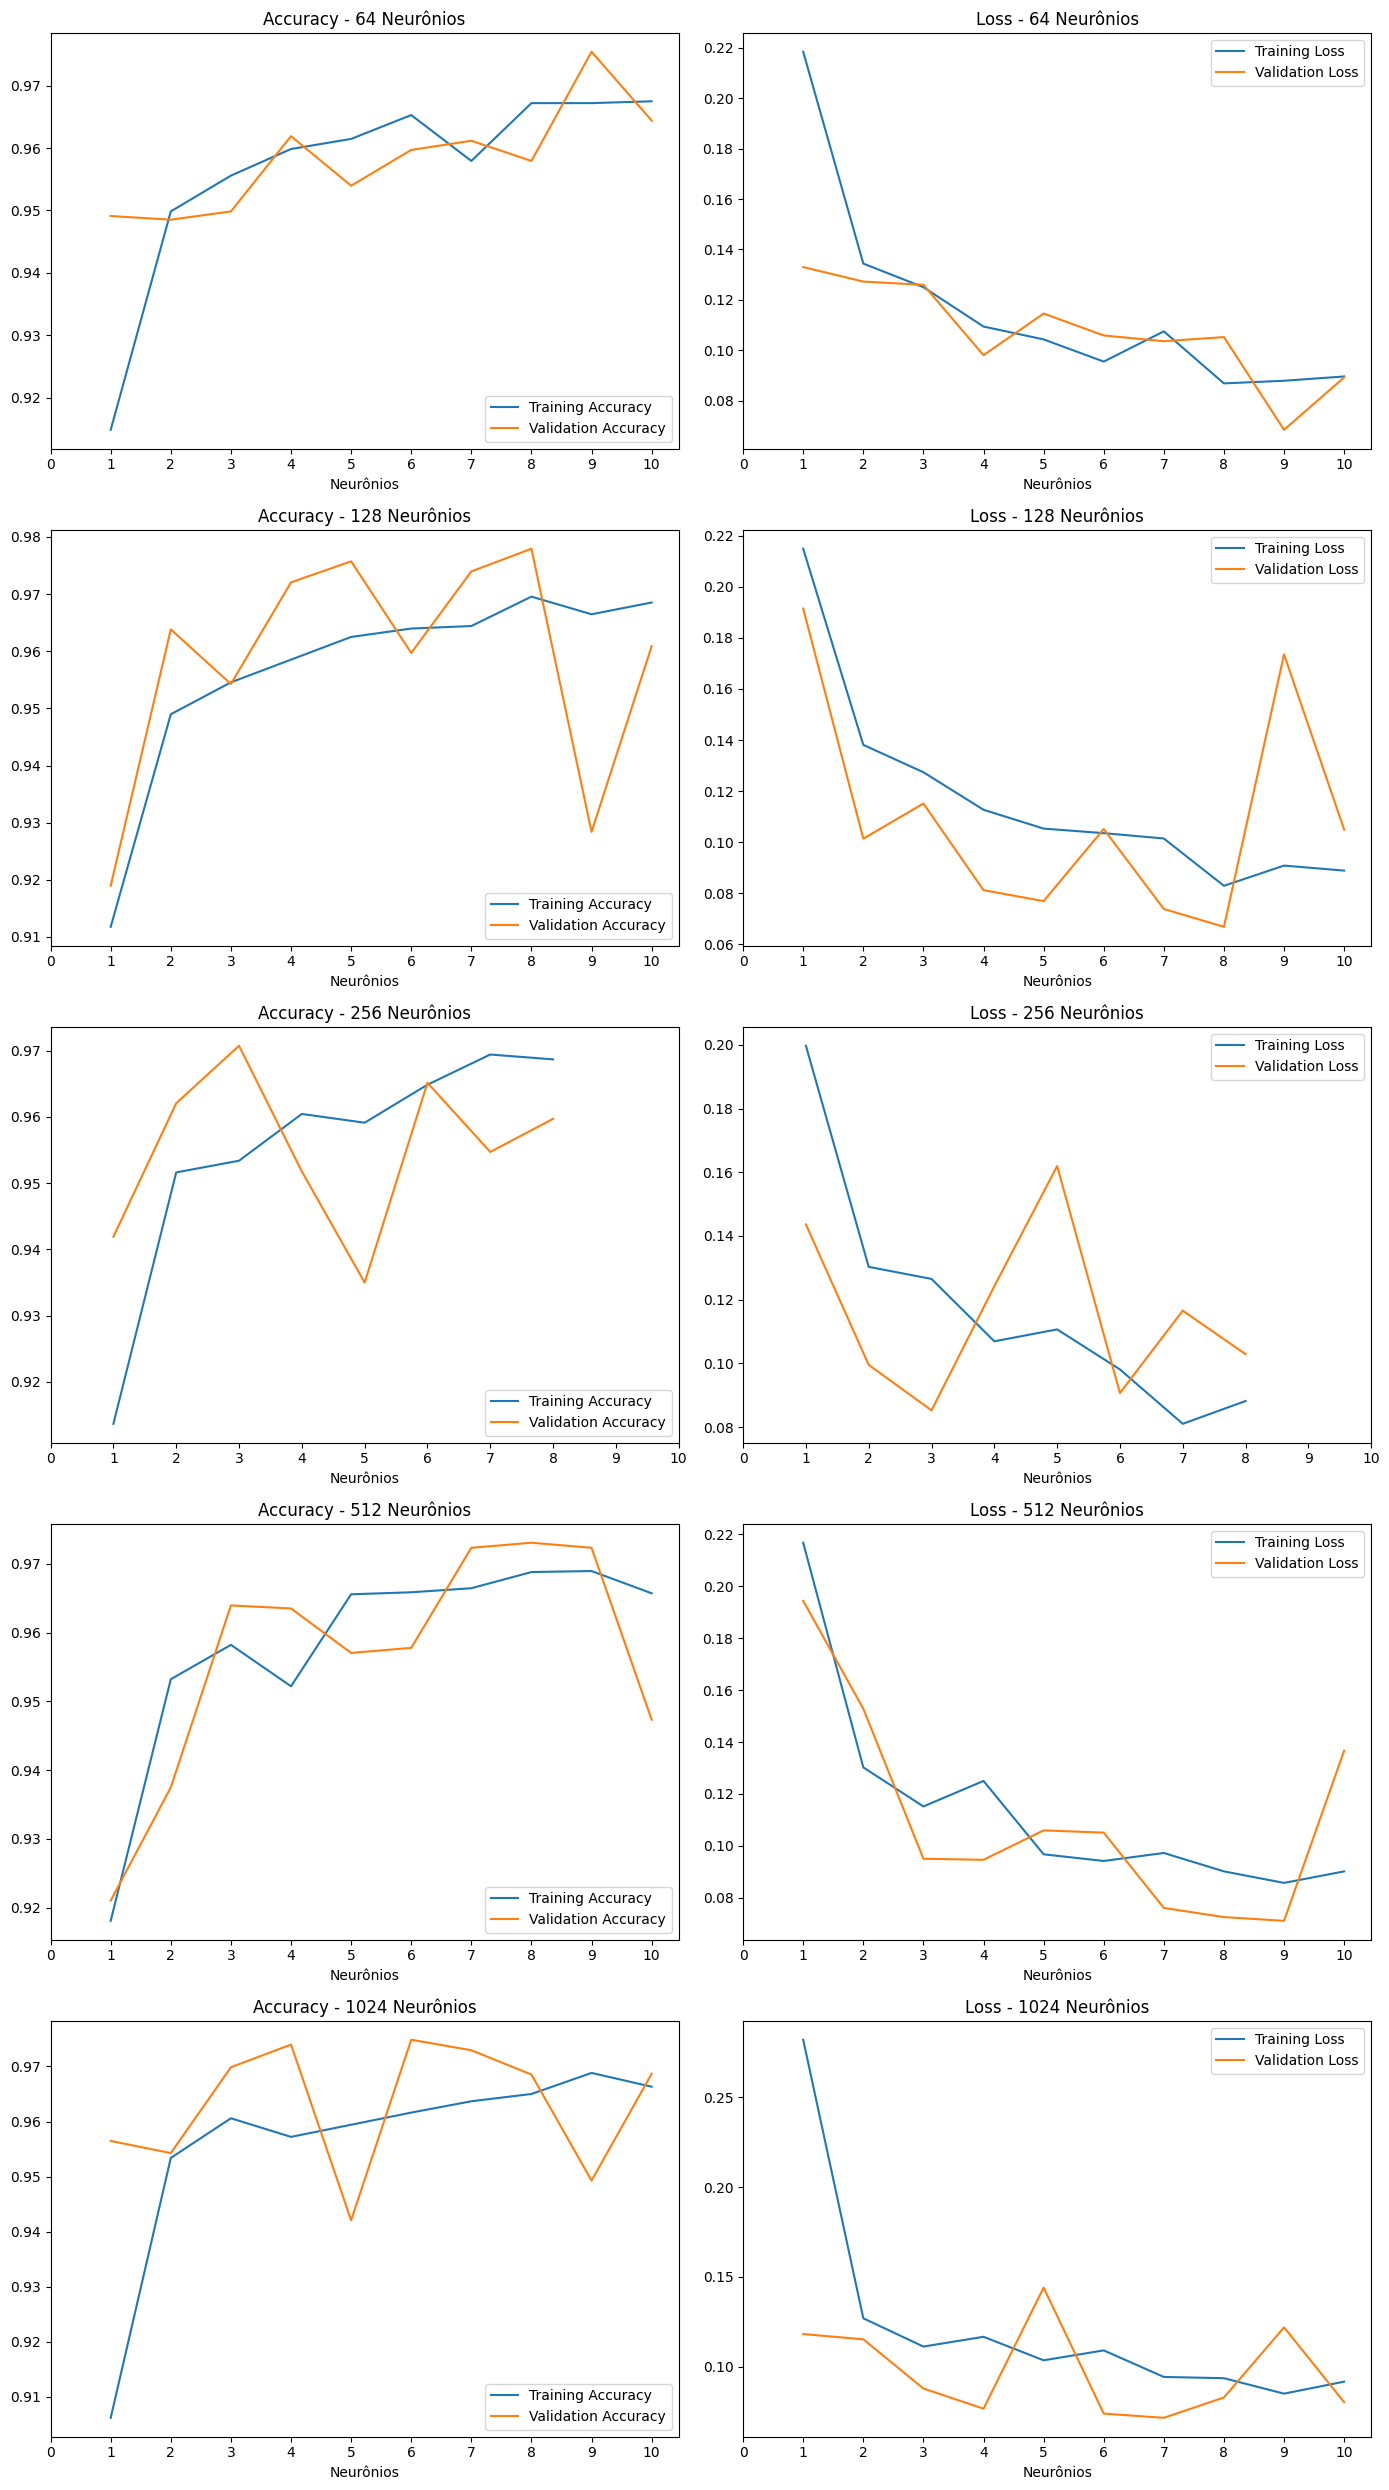

In [24]:
# 1. Calcule o número de linhas necessário
num_rows = len(dense_layer_neurons)

# 2. Ajuste o figsize para crescer conforme o número de linhas (ex: 5 polegadas por linha)
plt.figure(figsize=(14, 5 * num_rows))

for i, neurons_number in enumerate(dense_layer_neurons):
    # Extraindo dados...
    acc = histories[neurons_number].history['accuracy']
    val_acc = histories[neurons_number].history['val_accuracy']
    loss = histories[neurons_number].history['loss']
    val_loss = histories[neurons_number].history['val_loss']

    eixo_x = range(1, len(acc) + 1)

    # 3. Use num_rows aqui para a grade ser flexível
    # O índice 2*i + 1 (ímpar) sempre será a coluna da esquerda (Acurácia)
    # O índice 2*i + 2 (par) sempre será a coluna da direita (Loss)

    # Gráfico de Acurácia
    plt.subplot(num_rows, 2, 2*i + 1)
    plt.plot(eixo_x, acc, label='Training Accuracy')
    plt.plot(eixo_x, val_acc, label='Validation Accuracy')
    plt.xticks(range(0, 11))
    plt.legend(loc='lower right')
    plt.title(f'Accuracy - {neurons_number} Neurônios')
    plt.xlabel('Neurônios')

    # Gráfico de Perdas (Loss)
    plt.subplot(num_rows, 2, 2*i + 2)
    plt.plot(eixo_x, loss, label='Training Loss')
    plt.plot(eixo_x, val_loss, label='Validation Loss')
    plt.xticks(range(0, 11))
    plt.legend(loc='upper right')
    plt.title(f'Loss - {neurons_number} Neurônios')
    plt.xlabel('Neurônios')

plt.tight_layout()
plt.show()


RESULTADOS DO MODELO - TREINADO COM LIMITE DE 64 NEURÔNIOS


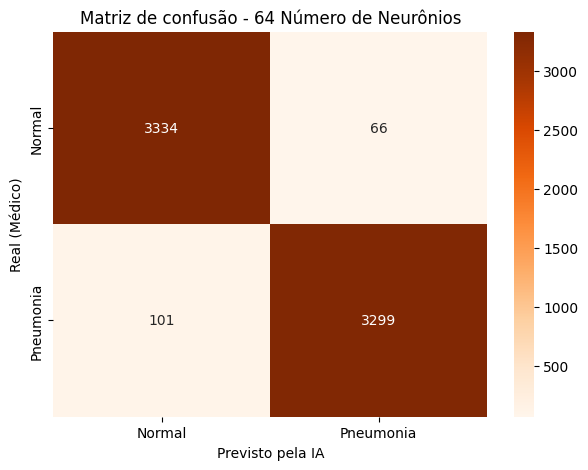


Relatório de Classificação (Limite de 64 Número de Neurônios):
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      3400
   Pneumonia       0.98      0.97      0.98      3400

    accuracy                           0.98      6800
   macro avg       0.98      0.98      0.98      6800
weighted avg       0.98      0.98      0.98      6800




RESULTADOS DO MODELO - TREINADO COM LIMITE DE 128 NEURÔNIOS


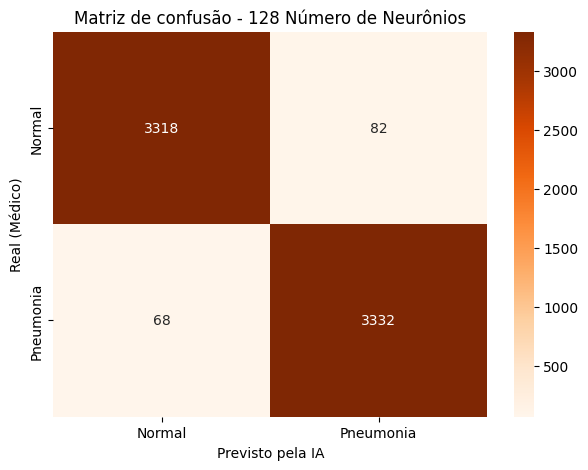


Relatório de Classificação (Limite de 128 Número de Neurônios):
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      3400
   Pneumonia       0.98      0.98      0.98      3400

    accuracy                           0.98      6800
   macro avg       0.98      0.98      0.98      6800
weighted avg       0.98      0.98      0.98      6800




RESULTADOS DO MODELO - TREINADO COM LIMITE DE 256 NEURÔNIOS


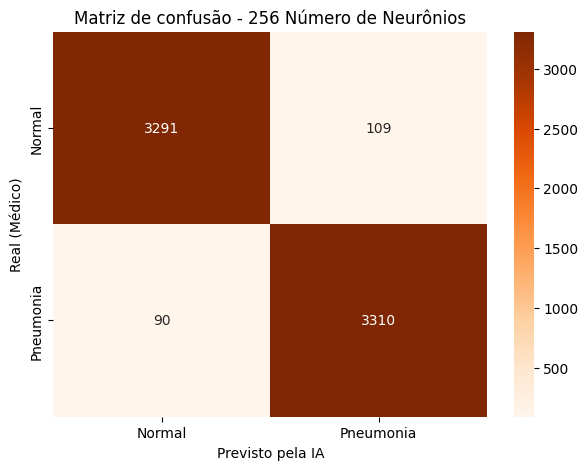


Relatório de Classificação (Limite de 256 Número de Neurônios):
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      3400
   Pneumonia       0.97      0.97      0.97      3400

    accuracy                           0.97      6800
   macro avg       0.97      0.97      0.97      6800
weighted avg       0.97      0.97      0.97      6800




RESULTADOS DO MODELO - TREINADO COM LIMITE DE 512 NEURÔNIOS


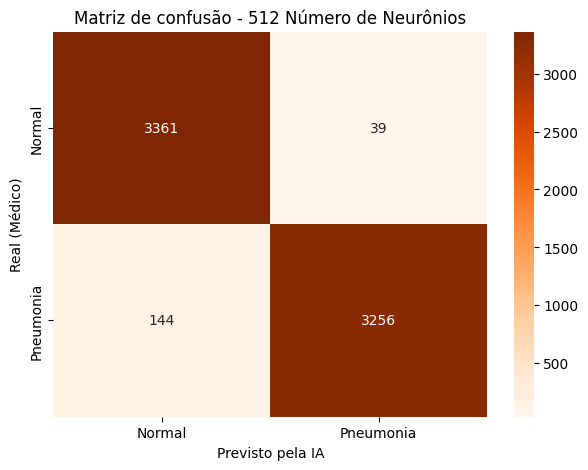


Relatório de Classificação (Limite de 512 Número de Neurônios):
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97      3400
   Pneumonia       0.99      0.96      0.97      3400

    accuracy                           0.97      6800
   macro avg       0.97      0.97      0.97      6800
weighted avg       0.97      0.97      0.97      6800




RESULTADOS DO MODELO - TREINADO COM LIMITE DE 1024 NEURÔNIOS


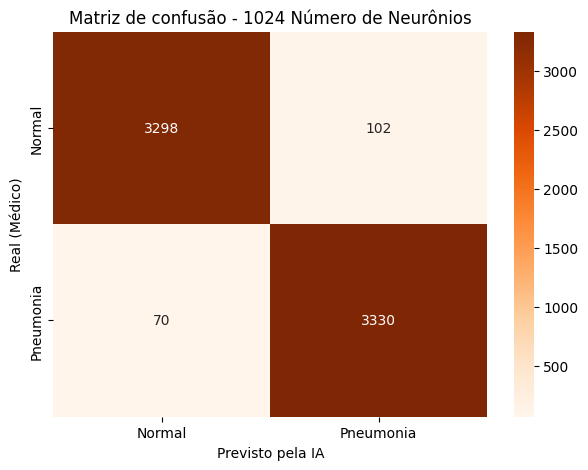


Relatório de Classificação (Limite de 1024 Número de Neurônios):
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97      3400
   Pneumonia       0.97      0.98      0.97      3400

    accuracy                           0.97      6800
   macro avg       0.97      0.97      0.97      6800
weighted avg       0.97      0.97      0.97      6800





In [23]:
for neurons_number in dense_layer_neurons:
    print(f'\n{"="*60}')
    print(f'RESULTADOS DO MODELO - TREINADO COM LIMITE DE {neurons_number} NEURÔNIOS')
    print(f'{"="*60}')

    y_true = []
    y_pred = []

    # Pegando as imagens e os labels do dataset de validação
    for images, labels in validation_dataset:
        # Usando o modelo específico salvo nesta chave do dicionário
        preds = models[neurons_number].predict(images, verbose=0)
        y_true.extend(labels.numpy())
        # Como a saída da Sigmoid é probabilidade (0 a 1), usamos o limiar de 0.5
        y_pred.extend((preds > 0.5).astype(int))

    # Aqui geramos a matriz
    cm = confusion_matrix(y_true, y_pred)

    # Plotando o gráfico
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'])
    plt.xlabel('Previsto pela IA')
    plt.ylabel('Real (Médico)')
    plt.title(f'Matriz de confusão - {neurons_number} Número de Neurônios')
    plt.show()

    # Relatório completo (Precision, Recall, F1)
    print(f"\nRelatório de Classificação (Limite de {neurons_number} Número de Neurônios):")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))
    print("\n")